In [1]:
# @title
import numpy as np
import time
import matplotlib.pyplot as plt

In [2]:
import numpy as np

import numpy as np

def Campo_capacitor(nx, ny, y0, l, d, Q, tol, max_iter=10000):
    """
    nx: distancia máxima en la dirección x, con separaciones de 0.2 cm.
    ny: distancia máxima en la dirección y.
    y0: distancia desde el borde superior hasta donde comienzan los capacitores.
    d: distancia entre los capacitores.
    Q: carga total en los capacitores.
    """
    V = np.zeros((ny, nx))   # primero y, luego x
    y1 = y0
    y2 = y0 + l

    # posiciones de las placas en x
    a = int(nx/2 - d/2)
    b = int(nx/2 + d/2)

    # verificaciones
    if y1 < 0 or y2 > ny:
        raise ValueError("La longitud vertical de las placas se sale del dominio.")
    if a < 0 or b >= nx:
        raise ValueError("Las placas se salen del dominio en x.")

    # condiciones fijas iniciales
    V[y1:y2, a] = Q
    V[y1:y2, b] = -Q

    for _ in range(max_iter):
        V2 = V.copy()

        # actualización Jacobi
        V[1:-1, 1:-1] = 0.25 * (
            V2[:-2, 1:-1] +
            V2[2:, 1:-1] +
            V2[1:-1, :-2] +
            V2[1:-1, 2:])
        V[0,1:-1]=0.25*(V[0,2:]+V[0,:-2]+V[1,1:-1])#esta parte es para solucionar los problemas en la frontera
        V[1:-1,0]=0.25*(V[2:,0]+V[:-2,0]+V[1:-1,1])
        V[1:-1,nx-1]=0.25*(V[2:,nx-1]+V[:-2,nx-1]+V[1:-1,nx-2])
        V[nx-1,1:-1]=0.25*(V[nx-1,2:]+V[nx-1,:-2]+V[nx-2,1:-1])
        V[0,0]=0.25*(V[0,1]+V[1,0])
        V[0,nx-1]=0.25*(V[0,nx-2]+V[1,nx-1])
        V[nx-1,0]=0.25*(V[nx-1,1]+V[nx-2,0])
        V[nx-1,nx-1]=0.25*(V[nx-1,nx-2]+V[nx-2,nx-1])

        # reimponer placas
        V[y1:y2, a] = Q
        V[y1:y2, b] = -Q

        # criterio de convergencia
        if np.max(np.abs(V - V2)) < tol:
            break

    return V

In [3]:
Campo_capacitor

<function __main__.Campo_capacitor(nx, ny, y0, l, d, Q, tol, max_iter=10000)>

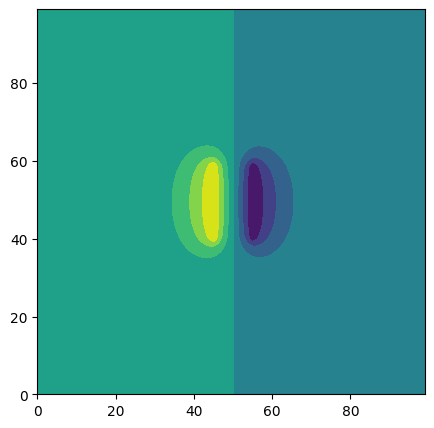

In [4]:
# @title
V=Campo_capacitor(100,100,40,20,10,1,10**-3)
plt.subplots(figsize=(5,5) )
plt.contourf(Campo_capacitor(100,100,40,20,10,1,10**-3))
plt.show()

In [6]:
dx=0.1
dy=0.1
Ey, Ex = np.gradient(-V, dy, dx)

In [5]:
esto está incompleto... debe graficar el campo...

SyntaxError: invalid syntax (2415243821.py, line 1)

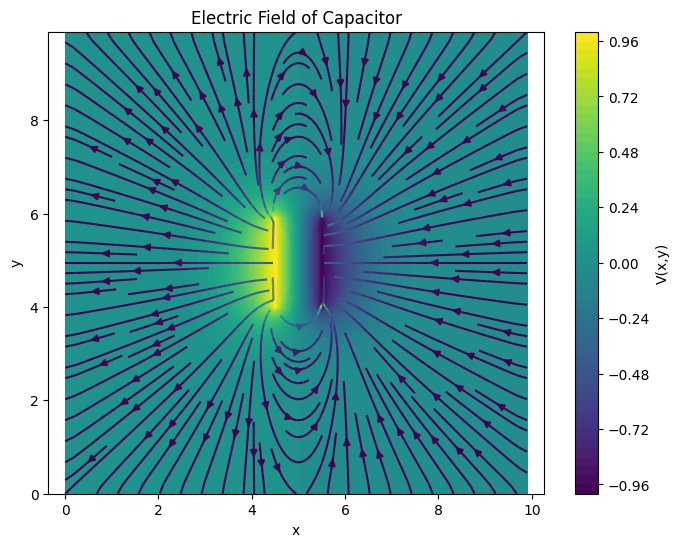

In [14]:
dx = 0.1
dy = 0.1

Ey, Ex = np.gradient(-V, dy, dx)


ny, nx = V.shape
x = np.arange(0, nx*dx, dx)
y = np.arange(0, ny*dy, dy)
X, Y = np.meshgrid(x, y)


E_mag = np.sqrt(Ex**2 + Ey**2)

plt.figure(figsize=(8,6))


plt.contourf(X, Y, V, levels=50)
plt.colorbar(label='V(x,y)')


plt.streamplot(X, Y, Ex, Ey, color=E_mag, density=1.5)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Campo electrico')
plt.axis('equal')

plt.show()